# IEEE-CIS Fraud Detection

## Notebook 2: Exploratory Data Analysis

This notebook explores the cleaned dataset to understand the distributions,
relationships, and patterns that distinguish fraudulent transactions from legitimate ones.
All findings here will directly inform feature engineering decisions in Notebook 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_theme(style='whitegrid', palette='muted')

In [2]:
df = pd.read_csv('/kaggle/input/notebooks/aliibtissam/01-data-cleaning/cleaned_data.csv')

print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["isFraud"].mean() * 100:.2f}%')

Shape: (590540, 422)
Fraud rate: 3.50%


## 1. Class Distribution

The target variable is heavily imbalanced. Only 3.5% of transactions are fraudulent.
This directly impacts our choice of evaluation metric — we use AUC-ROC instead of accuracy.

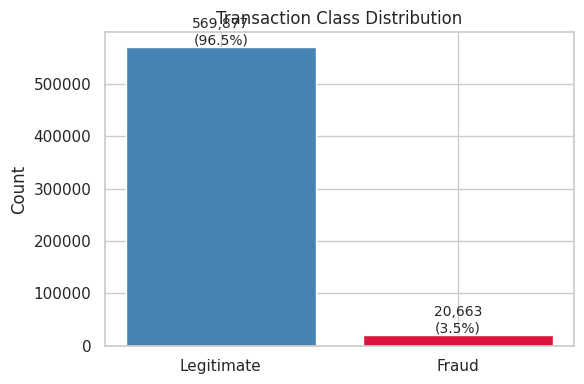

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['isFraud'].value_counts()
ax.bar(['Legitimate', 'Fraud'], counts.values, color=['steelblue', 'crimson'])
ax.set_title('Transaction Class Distribution')
ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 5000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Fraudulent transactions are slightly skewed toward higher amounts with a median of $75
compared to $68 for legitimate transactions. The distribution is wider for fraud,
indicating fraudsters attempt a broader range of transaction sizes.

## 2. Transaction Amount vs Fraud

Do fraudulent transactions tend to be larger or smaller than legitimate ones?

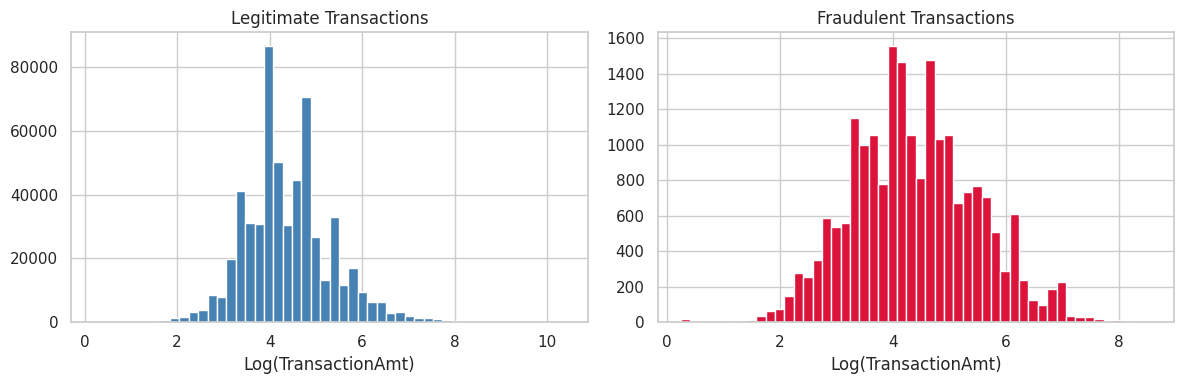

Legitimate - median amount: $68.50
Fraud      - median amount: $75.00


In [4]:
legitimate = df[df['isFraud'] == 0]['TransactionAmt'].apply(np.log1p)
fraud = df[df['isFraud'] == 1]['TransactionAmt'].apply(np.log1p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

legitimate.hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Legitimate Transactions')
axes[0].set_xlabel('Log(TransactionAmt)')

fraud.hist(bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Fraudulent Transactions')
axes[1].set_xlabel('Log(TransactionAmt)')

plt.tight_layout()
plt.show()

print(f'Legitimate - median amount: ${df[df["isFraud"]==0]["TransactionAmt"].median():.2f}')
print(f'Fraud      - median amount: ${df[df["isFraud"]==1]["TransactionAmt"].median():.2f}')

ProductCD = C has a fraud rate of 11.7%, more than three times the dataset average.
ProductCD = W has the lowest fraud rate at 2.0%. Product type is a strong feature for the model.

## 3. Fraud Rate by Product Type

Which product categories are most associated with fraud?
This tells us whether ProductCD will be a useful feature for the model.

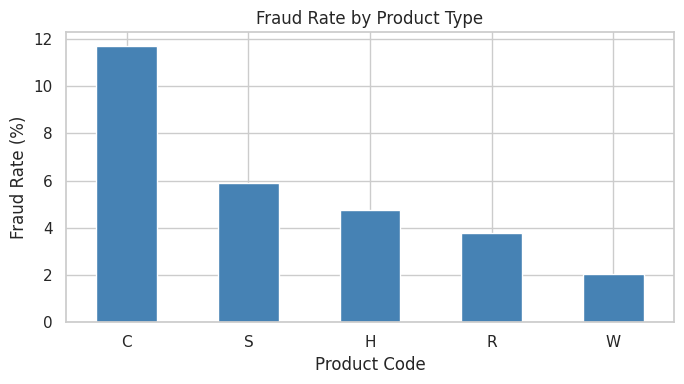

ProductCD
C   11.687
S    5.900
H    4.766
R    3.783
W    2.040
Name: isFraud, dtype: float64


In [5]:
product_fraud = df.groupby('ProductCD')['isFraud'].mean() * 100
product_fraud = product_fraud.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
product_fraud.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Fraud Rate by Product Type')
ax.set_xlabel('Product Code')
ax.set_ylabel('Fraud Rate (%)')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(product_fraud)

In [6]:
product_fraud = df.groupby('ProductCD')['isFraud'].mean() * 100
product_fraud = product_fraud.sort_values(ascending=False)
product_fraud

ProductCD
C   11.687
S    5.900
H    4.766
R    3.783
W    2.040
Name: isFraud, dtype: float64

Product type C has a fraud rate of 11.7%, more than three times the dataset average of 3.5%.
Product type W has the lowest fraud rate at 2.0%. ProductCD is a strong categorical feature
and will be label encoded in feature engineering.

## 4. Fraud Rate Over Time

TransactionDT is a time delta in seconds from a fixed reference point.
Converting it to days reveals whether fraud follows any temporal pattern.

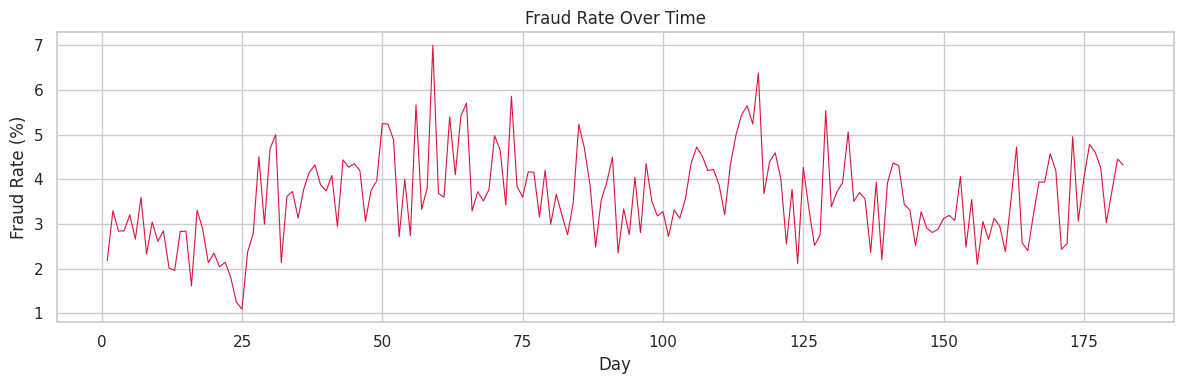

In [7]:
df['transaction_day'] = (df['TransactionDT'] / (60 * 60 * 24)).astype(int)

daily_fraud = df.groupby('transaction_day')['isFraud'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
daily_fraud.plot(ax=ax, color='crimson', linewidth=0.8)
ax.set_title('Fraud Rate Over Time')
ax.set_xlabel('Day')
ax.set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

Fraud rate fluctuates between 2% and 7% across the 180-day period with no clear seasonal trend.
The daily variation suggests time-based features such as day of week will be useful in the model.
The temporary dip around day 25 may reflect an external event or data collection gap.

## 5. Fraud Rate by Email Domain

The purchaser email domain may reveal suspicious patterns.
Fraudsters often use disposable or obscure email addresses.
We look at domains with at least 500 transactions to avoid noise from rare domains.

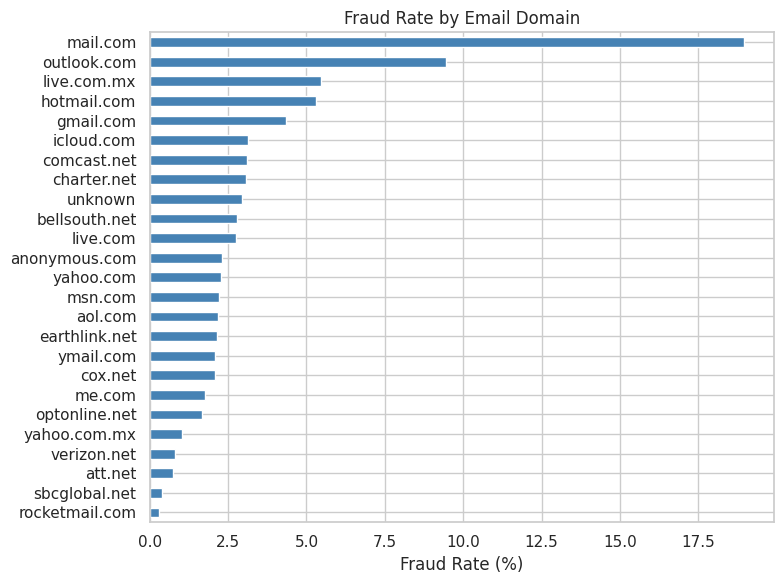

P_emaildomain
mail.com      18.962
outlook.com    9.458
live.com.mx    5.474
hotmail.com    5.295
gmail.com      4.354
Name: isFraud, dtype: float64


In [8]:
email_counts = df.groupby('P_emaildomain')['isFraud'].count()
valid_domains = email_counts[email_counts >= 500].index

email_fraud = df[df['P_emaildomain'].isin(valid_domains)].groupby('P_emaildomain')['isFraud'].mean() * 100
email_fraud = email_fraud.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
email_fraud.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Fraud Rate by Email Domain')
ax.set_xlabel('Fraud Rate (%)')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

print(email_fraud.sort_values(ascending=False).head(5))

mail.com has a fraud rate of 18.9%, more than five times the dataset average.
Free disposable email services with no identity verification are strongly associated with fraud.
This finding will be used in feature engineering to create a high-risk email domain flag.

## 6. Fraud Rate by Card Type

Card network and card type may reveal whether certain payment methods
are more frequently used in fraudulent transactions.

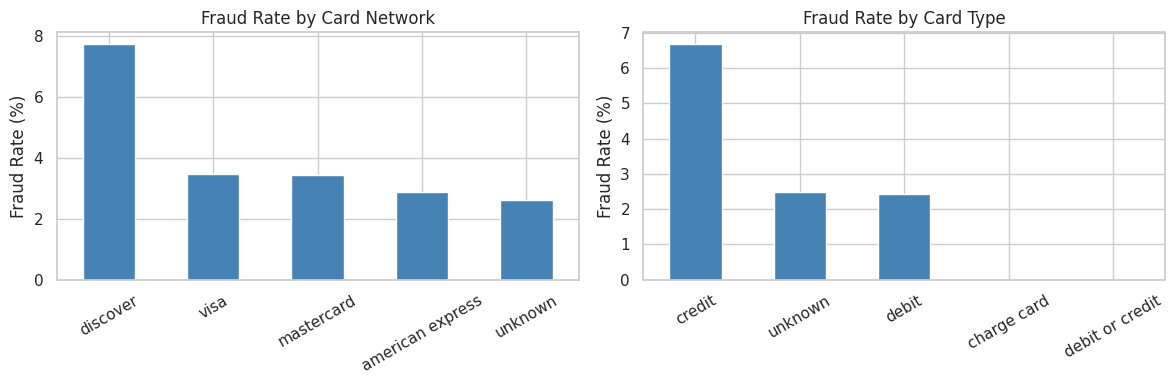

Card Network:
card4
discover           7.728
visa               3.476
mastercard         3.433
american express   2.870
unknown            2.600
Name: isFraud, dtype: float64

Card Type:
card6
credit            6.678
unknown           2.482
debit             2.426
charge card       0.000
debit or credit   0.000
Name: isFraud, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

card4_fraud = df.groupby('card4')['isFraud'].mean() * 100
card4_fraud = card4_fraud.sort_values(ascending=False)
card4_fraud.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Fraud Rate by Card Network')
axes[0].set_xlabel('')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

card6_fraud = df.groupby('card6')['isFraud'].mean() * 100
card6_fraud = card6_fraud.sort_values(ascending=False)
card6_fraud.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Fraud Rate by Card Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Card Network:')
print(card4_fraud)
print()
print('Card Type:')
print(card6_fraud)

Discover cards have a fraud rate of 7.7%, more than double Visa and Mastercard.
Credit cards have a fraud rate of 6.7% compared to 2.4% for debit cards — fraudsters
prefer credit cards due to higher limits and no PIN requirement.
Both card4 and card6 are strong categorical features for the model.

## 7. V Feature Correlation with Fraud

There are 339 Vesta-engineered features with masked meanings. We compute their
correlation with the fraud label to identify which ones carry the strongest signal
and which are likely noise.

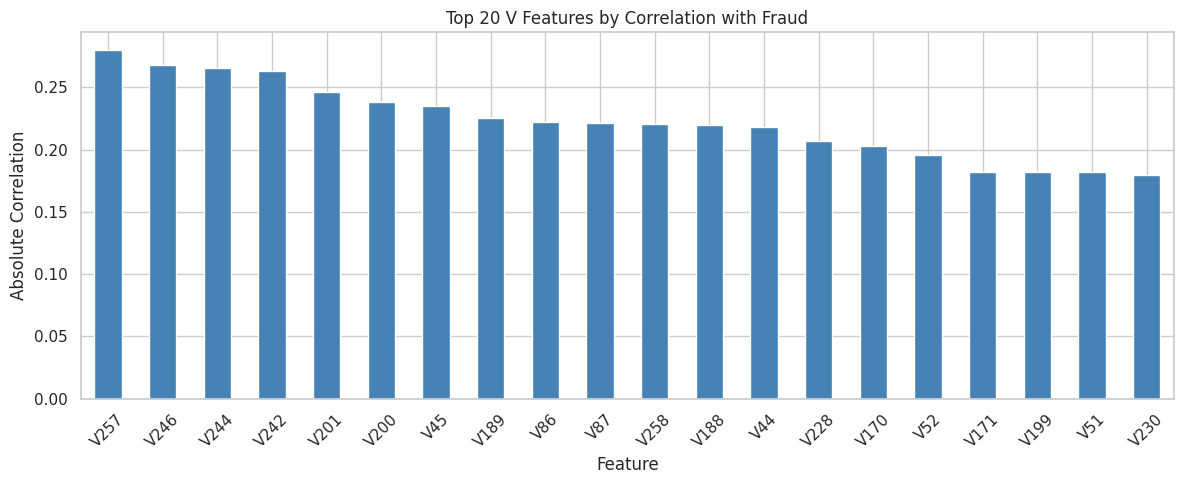

V257   0.280
V246   0.268
V244   0.266
V242   0.263
V201   0.246
V200   0.238
V45    0.235
V189   0.226
V86    0.222
V87    0.222
Name: isFraud, dtype: float64


In [10]:
v_cols = [col for col in df.columns if col.startswith('V')]

v_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
v_corr_abs = v_corr.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
v_corr_abs.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Top 20 V Features by Correlation with Fraud')
ax.set_xlabel('Feature')
ax.set_ylabel('Absolute Correlation')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(v_corr_abs.head(10))

## Summary

| Finding | Detail |
|---|---|
| Class imbalance | 96.5% legitimate, 3.5% fraud |
| Transaction amount | Fraud transactions skewed slightly higher, median $75 vs $68 |
| Product type | ProductCD = C has 11.7% fraud rate, 3x the average |
| Email domain | mail.com has 18.9% fraud rate, 5x the average |
| Card network | Discover has 7.7% fraud rate, double Visa and Mastercard |
| Card type | Credit cards have 6.7% fraud rate vs 2.4% for debit |
| Time | Fraud rate fluctuates daily between 2-7%, time features will be useful |
| V features | V257, V246, V244, V242 are the strongest Vesta engineered features |

These findings directly inform feature engineering in Notebook 3.